# 03 - Exploratory Data Analysis (EDA)
**Project:** DS Job Recommend (Job Level Prediction & Recommendation System)  
**Assigned Role:** **PERSON 2 — Branch:** `feature/visualization`  
**Input Dataset:** `data/processed/postings_clean.csv`  
**Target Variable:** `formatted_experience_level`

---
### TABLE OF CONTENTS
1. Library Imports & Data Loading
2. Descriptive Statistics
3. Missing Value & Duplicate Check
4. Numerical Distribution (Histplot + KDE)
5. Outlier Detection (Boxplot)
6. Correlation Matrix (Heatmap)
7. Feature Relationship (Scatter Matrix)
8. Target Variable Analysis (Countplot)
9. Salary Comparison by Experience Level (Boxplot)
---

## 1. Library Imports & Data Loading

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
warnings.filterwarnings("ignore")

In [2]:
from pathlib import Path
import sys, os

ROOT_DIR = Path('__file__').resolve().parent.parent if '__file__' in locals() else Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

if (ROOT_DIR / 'data' / 'processed').exists():
    PROCESSED = ROOT_DIR / 'data' / 'processed'
elif Path('../data/processed').exists():
    PROCESSED = Path('../data/processed')
else:
    PROCESSED = Path('data/processed')

df = pd.read_csv(PROCESSED / 'postings_clean.csv', low_memory=False)
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(df.columns.tolist())
print(df.head())
print(df.tail())

Dataset: 123,849 rows x 31 columns
['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']
     job_id            company_name  \
0    921716   Corcoran Sawyer Smith   
1   1829192                     NaN   
2  10998357   The National Exemplar   
3  23221523  Abrams Fensterman, LLP   
4  35982263                     NaN   

                                               title  \
0                              Marketing Coordinator   
1                  Mental Health Therapist/Counselor   
2                        Assitant Restaurant Manager   
3  Senior Elder Law / Trust

## 2. Descriptive Statistics

In [3]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6266 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applies                     23320 non-null   float64
 13  original_listed_time     

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
count,1.238490e+05,122130,123849,123842,2.979300e+04,36073,123849,1.221320e+05,122160.000000,6266.000000,...,2439,1.238490e+05,83881,123849.0,123849,36073,36073,3.605900e+04,102977.000000,96434.000000
unique,NaN,24423,72051,107550,NaN,5,8526,NaN,NaN,NaN,...,2211,NaN,4443,NaN,7,6,1,NaN,NaN,NaN
top,NaN,Liberty Healthcare and Rehabilitation Services,Sales Manager,Position Summary: Our Sales Manager has managi...,NaN,YEARLY,United States,NaN,NaN,NaN,...,This position requires the following skills: E...,NaN,www.click2apply.net,NaN,FULL_TIME,USD,BASE_SALARY,NaN,NaN,NaN
freq,NaN,1108,673,475,NaN,20298,8125,NaN,NaN,NaN,...,28,NaN,3811,NaN,98814,36058,36073,NaN,NaN,NaN
mean,3.896402e+09,NaN,NaN,NaN,9.193942e+04,NaN,NaN,1.220401e+07,14.618247,22064.808940,...,NaN,1.713204e+12,NaN,0.0,NaN,NaN,NaN,9.972543e+04,50400.491887,28713.879887
std,8.404355e+07,NaN,NaN,NaN,7.011101e+05,NaN,NaN,2.554143e+07,85.903598,52303.851683,...,NaN,3.989122e+08,NaN,0.0,NaN,NaN,NaN,5.432585e+05,30252.232515,16015.929825
min,9.217160e+05,NaN,NaN,NaN,1.000000e+00,NaN,NaN,1.009000e+03,1.000000,9.000000,...,NaN,1.711317e+12,NaN,0.0,NaN,NaN,NaN,1.200000e+02,1001.000000,1003.000000
25%,3.894587e+09,NaN,NaN,NaN,4.828000e+01,NaN,NaN,1.435200e+04,3.000000,19.000000,...,NaN,1.712886e+12,NaN,0.0,NaN,NaN,NaN,5.200000e+04,24112.000000,13121.000000
50%,3.901998e+09,NaN,NaN,NaN,8.000000e+04,NaN,NaN,2.269650e+05,4.000000,25.530000,...,NaN,1.713408e+12,NaN,0.0,NaN,NaN,NaN,8.250000e+04,48059.000000,29183.000000
75%,3.904707e+09,NaN,NaN,NaN,1.400000e+05,NaN,NaN,8.047188e+06,8.000000,2523.250000,...,NaN,1.713484e+12,NaN,0.0,NaN,NaN,NaN,1.250000e+05,78201.000000,42077.000000


## 3. Missing Value & Duplicate Check

In [4]:
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== MISSING RATIO (%) ===')
print((df.isnull().sum() / df.shape[0]) * 100)
print(f'\n=== DUPLICATE RATIO: {(df.duplicated().sum() / df.shape[0]) * 100:.2f}% ===')

=== MISSING VALUES ===
job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117583
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                     0
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency       

## 4. Numerical Distribution (Histplot + KDE)

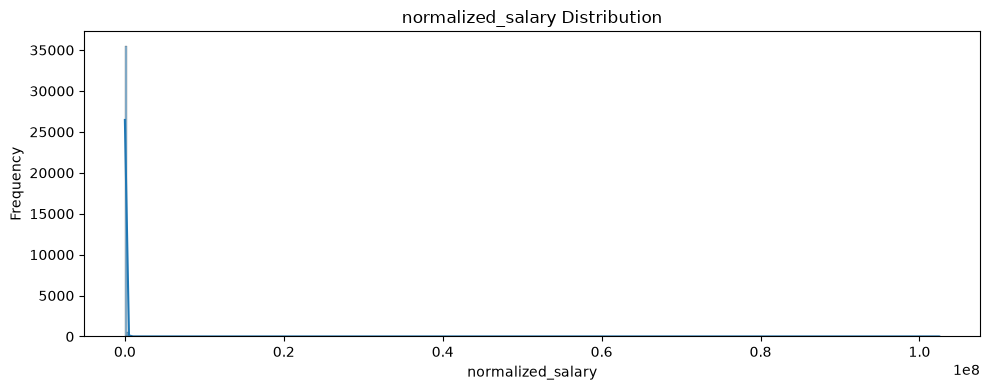

>>> normalized_salary:
    Spread from 120 to 102,500,000
    Concentrated in range 52,000 - 125,000 (Q1-Q3)
    Mean: 99,725 | Median: 82,500



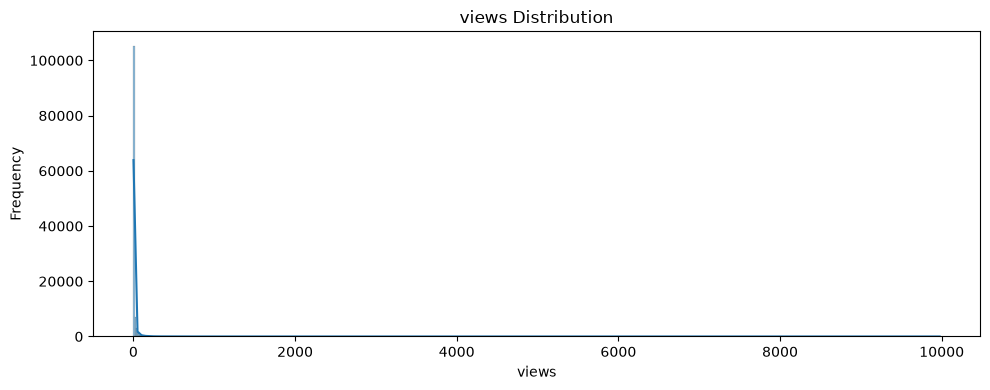

>>> views:
    Spread from 1 to 9,975
    Concentrated in range 3 - 8 (Q1-Q3)
    Mean: 15 | Median: 4



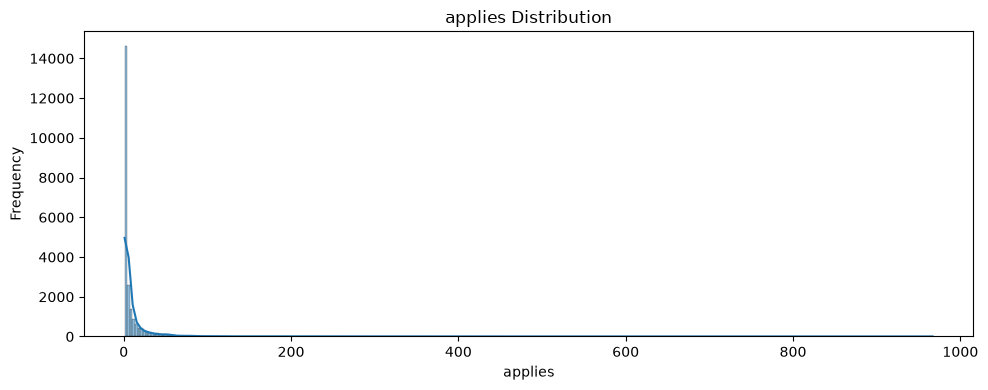

>>> applies:
    Spread from 1 to 967
    Concentrated in range 1 - 8 (Q1-Q3)
    Mean: 11 | Median: 3



In [5]:
NUM_COLS = [c for c in ['normalized_salary', 'views', 'applies']
            if c in df.columns]

for col in NUM_COLS:
    data = df[col].dropna()
    
    plt.figure(figsize=(10, 4))
    sns.histplot(data, kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    print(f'>>> {col}:')
    print(f'    Spread from {data.min():,.0f} to {data.max():,.0f}')
    print(f'    Concentrated in range {q1:,.0f} - {q3:,.0f} (Q1-Q3)')
    print(f'    Mean: {data.mean():,.0f} | Median: {data.median():,.0f}')
    print()

## 5. Outlier Detection (Boxplot)

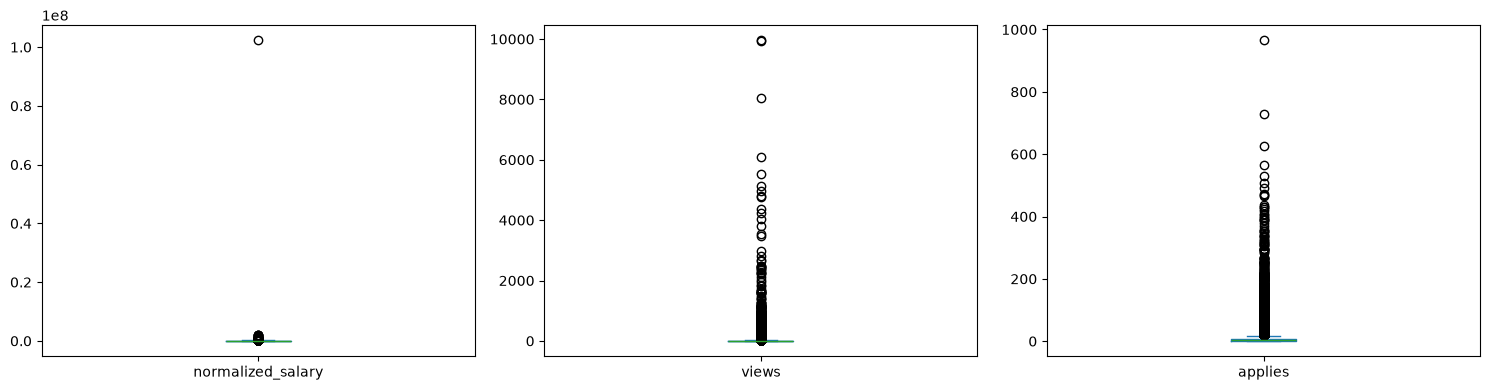

In [6]:
if NUM_COLS:
    n = len(NUM_COLS)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    
    df[NUM_COLS].plot(kind='box', subplots=True, layout=(nrows, ncols),
                      figsize=(5*ncols, 4*nrows))
    plt.tight_layout()
    plt.show()

## 6. Correlation Matrix (Heatmap)

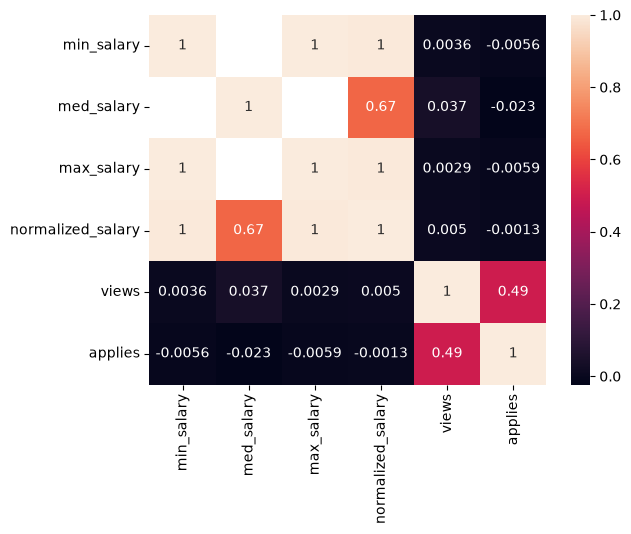

In [7]:
all_num = [c for c in ['min_salary', 'med_salary', 'max_salary',
                        'normalized_salary', 'views', 'applies']
           if c in df.columns]

if len(all_num) >= 2:
    corr = df[all_num].corr(numeric_only=True)
    plt.tight_layout()
    sns.heatmap(corr, annot=True)
    plt.show()

## 7. Feature Relationship (Scatter Matrix)

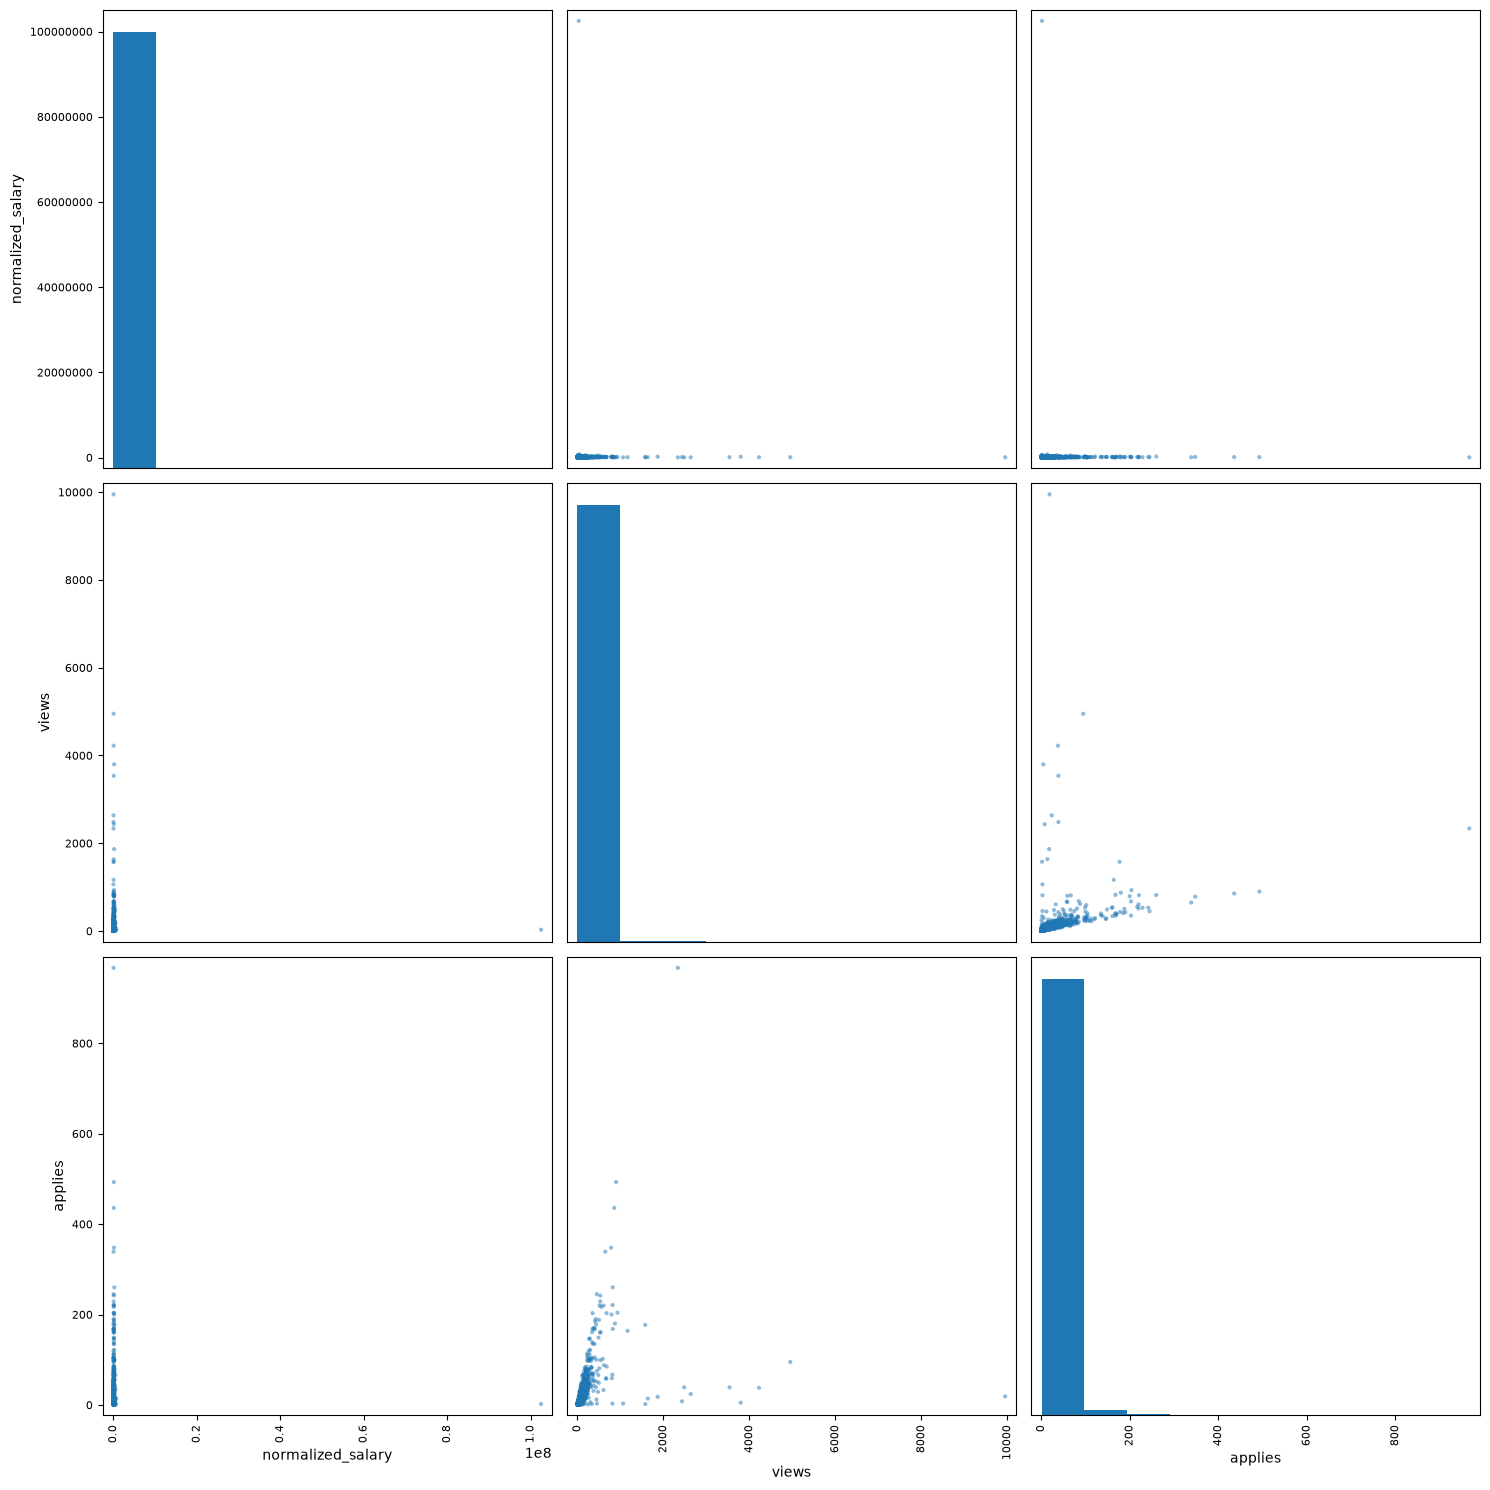

In [8]:
scatter_cols = [c for c in ['normalized_salary', 'views', 'applies']
                if c in df.columns]

if len(scatter_cols) >= 2:
    sample = df[scatter_cols].dropna()
    if len(sample) > 3000:
        sample = sample.sample(3000, random_state=42)
    scatter_matrix(sample, figsize=(15, 15))
    plt.tight_layout()
    plt.show()

## 8. Target Variable Analysis (Countplot)

=== TARGET DISTRIBUTION ===
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64


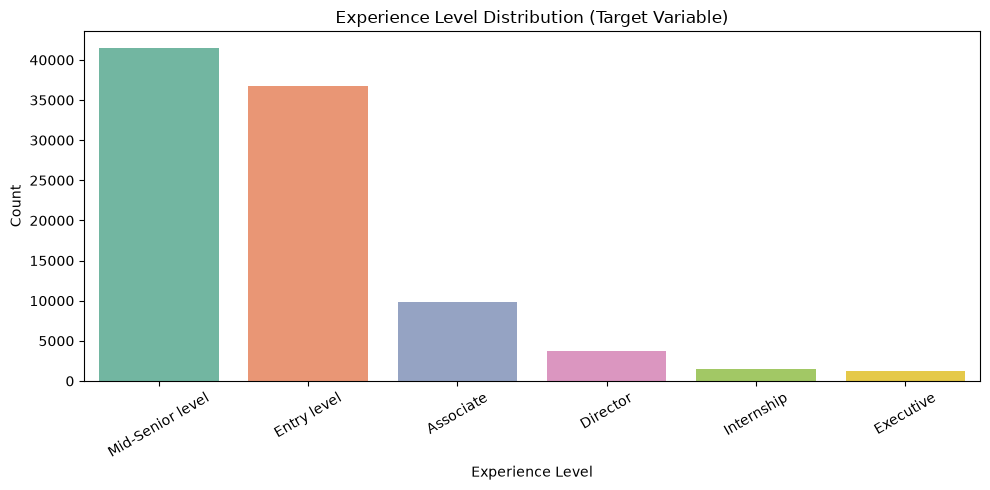

In [9]:
TARGET = 'formatted_experience_level'

if TARGET in df.columns:
    print('=== TARGET DISTRIBUTION ===')
    print(df[TARGET].value_counts())
    
    plt.figure(figsize=(10, 5))
    sns.countplot(x=TARGET, data=df.dropna(subset=[TARGET]),
                  order=df[TARGET].value_counts().index,
                  palette='Set2')
    plt.title('Experience Level Distribution (Target Variable)')
    plt.xlabel('Experience Level')
    plt.ylabel('Count')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print(f'Column {TARGET} not found in dataset.')

## 9. Salary Comparison by Experience Level (Boxplot)

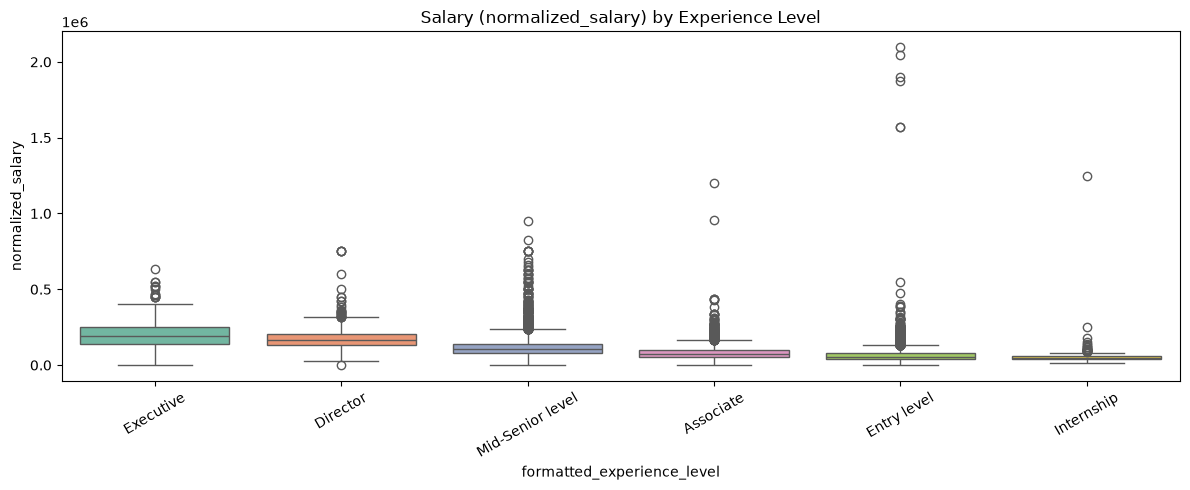

In [10]:
sal_col = next((c for c in ['normalized_salary', 'med_salary'] if c in df.columns), None)

if sal_col and TARGET in df.columns:
    plot_df = df[[TARGET, sal_col]].dropna()
    order = plot_df.groupby(TARGET)[sal_col].median().sort_values(ascending=False).index
    
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=plot_df, x=TARGET, y=sal_col,
                order=order, palette='Set2')
    plt.title(f'Salary ({sal_col}) by Experience Level')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

---
## CONCLUSION

Key findings from EDA:

1. **Distribution**: Salary and views columns are right-skewed, need log-transformation before modeling.
2. **Missing values**: Many columns have very high missing ratio (salary, applies...), need handling.
3. **Outliers**: Salary features contain many outliers, need removal or treatment.
4. **Correlation**: Salary columns (min, max, normalized) are highly correlated (multicollinearity) → keep only 1.
5. **Class imbalance**: Target variable is imbalanced → use SMOTE or class_weight during modeling.

---
**Exploratory Data Analysis completed!**